In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from pathlib import Path
import pandas as pd

data_dir = Path("../../data")
X_train = pd.read_csv(data_dir / "X_train.csv")
X_test = pd.read_csv(data_dir / "X_test.csv")
y_train = pd.read_csv(data_dir / "y_train.csv").values.ravel()
y_test = pd.read_csv(data_dir / "y_test.csv").values.ravel()

print("Loaded:")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

Loaded:
X_train: (226482, 36)
X_test:  (11282, 36)
y_train: (226482,)
y_test:  (11282,)


In [3]:
from src.predictors.predictors import EnsembleLearner
from src.evaluation.evaluate_classifier import evaluate_classifier, print_classifier_results


def print_evaluation(sub_model, X_train, X_test, y_train, y_test):
    sub_model_eval = clone(sub_model)
    sub_model_eval.fit(X_train, y_train)
    results = evaluate_classifier(
        sub_model_eval,
        X_train,
        X_test,
        y_train,
        y_test,
    )
    print_classifier_results(results)

model = EnsembleLearner(meta_test_size=0.15)
print("Initializing model...")

Initializing model...


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone

# Add Logistic Regression (Add scaling and L2 regularization)
logistic_regression = LogisticRegression(
    C=0.1,
    solver='lbfgs',
    l1_ratio=0,
    max_iter=10000
)
print_evaluation(logistic_regression, X_train, X_test, y_train, y_test)
model.add_learner("Logistic Regression with L2", logistic_regression)

Classifier Evaluation
Train games     : 226,482
Test games      : 11,282

Train accuracy  : 72.04%
Test accuracy   : 71.14%

Train log loss  : 0.5429
Test log loss   : 0.5501

Train ROC-AUC   : 0.7978
Test ROC-AUC    : 0.7898

Train confusion matrix:
[[81581 31660]
 [31660 81581]]

Test confusion matrix:
[[4013 1628]
 [1628 4013]]


In [5]:
from lightgbm import LGBMClassifier

# Add LightGBM (The dominant algorithm for Men's data)
lightgbm = LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.02,
    max_depth=5,
    num_leaves=31,
    min_child_samples=40,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=2.0,
    random_state=42,
    verbose=-1,
)
print_evaluation(lightgbm, X_train, X_test, y_train, y_test)
model.add_learner("LightGBM", lightgbm)

Classifier Evaluation
Train games     : 226,482
Test games      : 11,282

Train accuracy  : 72.75%
Test accuracy   : 71.32%

Train log loss  : 0.5311
Test log loss   : 0.5457

Train ROC-AUC   : 0.8077
Test ROC-AUC    : 0.7934

Train confusion matrix:
[[82387 30854]
 [30865 82376]]

Test confusion matrix:
[[4016 1625]
 [1611 4030]]


In [6]:
from xgboost import XGBClassifier

# Add XGBoost (Constrain depth to prevent memorization)
xgboost = XGBClassifier(
    n_estimators=800,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.6,
    colsample_bytree=0.6,
    random_state=42,
)
print_evaluation(xgboost, X_train, X_test, y_train, y_test)
model.add_learner("XGBoost", xgboost)

Classifier Evaluation
Train games     : 226,482
Test games      : 11,282

Train accuracy  : 73.14%
Test accuracy   : 71.40%

Train log loss  : 0.5260
Test log loss   : 0.5454

Train ROC-AUC   : 0.8123
Test ROC-AUC    : 0.7936

Train confusion matrix:
[[82800 30441]
 [30381 82860]]

Test confusion matrix:
[[4028 1613]
 [1614 4027]]


In [7]:
from sklearn.ensemble import RandomForestClassifier

# Add Random Forest
random_forest = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=10,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1,
)
print_evaluation(random_forest, X_train, X_test, y_train, y_test)
model.add_learner("Random Forest", random_forest)

Classifier Evaluation
Train games     : 226,482
Test games      : 11,282

Train accuracy  : 75.61%
Test accuracy   : 70.94%

Train log loss  : 0.4984
Test log loss   : 0.5481

Train ROC-AUC   : 0.8426
Test ROC-AUC    : 0.7913

Train confusion matrix:
[[85625 27616]
 [27628 85613]]

Test confusion matrix:
[[4001 1640]
 [1638 4003]]


In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Add KNN classifier
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=35,
        weights="distance",
        metric="minkowski",
        p=2,
    ))
])
print_evaluation(knn, X_train, X_test, y_train, y_test)
model.add_learner("KNN Classifier", knn)

Classifier Evaluation
Train games     : 226,482
Test games      : 11,282

Train accuracy  : 99.57%
Test accuracy   : 70.32%

Train log loss  : 0.0086
Test log loss   : 0.6664

Train ROC-AUC   : 0.9999
Test ROC-AUC    : 0.7747

Train confusion matrix:
[[112832    409]
 [   571 112670]]

Test confusion matrix:
[[3971 1670]
 [1678 3963]]


In [9]:
from sklearn.neural_network import MLPClassifier

# Add Basic Neural Network
mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        alpha=1e-3,
        learning_rate_init=1e-3,
        max_iter=300,
        early_stopping=True,
        random_state=42,
    ))
])
print_evaluation(mlp, X_train, X_test, y_train, y_test)
model.add_learner("Basic Neural Network", mlp)

Classifier Evaluation
Train games     : 226,482
Test games      : 11,282

Train accuracy  : 72.37%
Test accuracy   : 71.12%

Train log loss  : 0.5370
Test log loss   : 0.5489

Train ROC-AUC   : 0.8026
Test ROC-AUC    : 0.7905

Train confusion matrix:
[[81423 31818]
 [30756 82485]]

Test confusion matrix:
[[3979 1662]
 [1596 4045]]


Partitioning data to prevent leakage...
Training base learners...
Logistic Regression with L2 train=0.7200  test=0.7230
LightGBM             train=0.7282  test=0.7235
XGBoost              train=0.7323  test=0.7247
Random Forest        train=0.7596  test=0.7214
KNN Classifier       train=0.9959  test=0.7085
Basic Neural Network train=0.7228  test=0.7219
Generating meta-features...
Training meta-learner...
Matrix 	ilde{E}^T * 	ilde{E} (Error Correlation):
[[1.     0.8884 0.8956 0.8296 0.2597 0.9117]
 [0.8884 1.     0.9559 0.8811 0.2625 0.8797]
 [0.8956 0.9559 1.     0.8865 0.2648 0.8873]
 [0.8296 0.8811 0.8865 1.     0.2881 0.833 ]
 [0.2597 0.2625 0.2648 0.2881 1.     0.2612]
 [0.9117 0.8797 0.8873 0.833  0.2612 1.    ]]


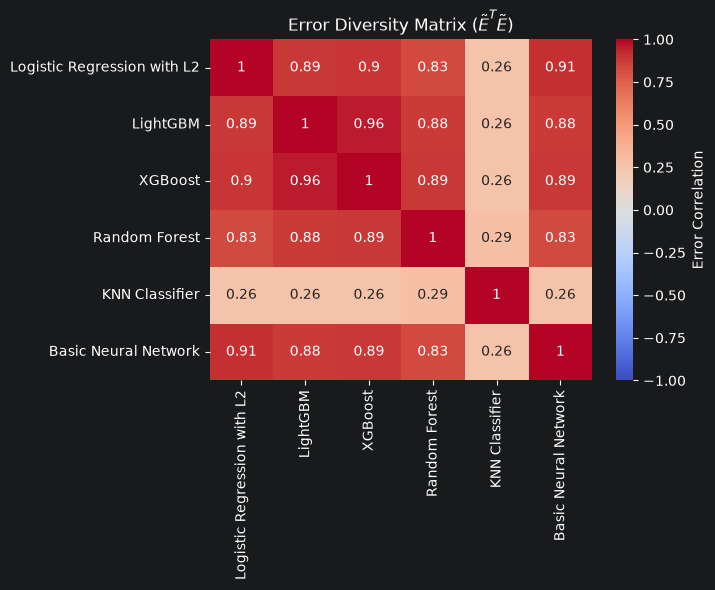

In [11]:
# Train the architecture
model.fit(X_train, y_train)
model.plot_error_heatmap(X_train, y_train)

In [12]:
# Where did we end up
results = evaluate_classifier(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
)
print_classifier_results(results)

Classifier Evaluation
Train games     : 226,482
Test games      : 11,282

Train accuracy  : 73.37%
Test accuracy   : 71.31%

Train log loss  : 0.5259
Test log loss   : 0.5504

Train ROC-AUC   : 0.8153
Test ROC-AUC    : 0.7931

Train confusion matrix:
[[83264 29977]
 [30342 82899]]

Test confusion matrix:
[[4023 1618]
 [1619 4022]]
